In [1]:
import numpy as np
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

In [9]:
df = pd.read_csv("data/mnist_train_small.csv")
df.head()

,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
X = df.iloc[:,1:]
y = df.iloc[:, 0]

# Feature Importance 

### It tells which feature is more important in predicting the target.

### Per-node importance:

`n_i = (Nₜ/N) [impurity - (N_t_R/Nₜ · right_impurity) - (N_t_L/Nₜ · left_impurity)]`

### Feature Importance of kth node:

`fi_k = Σ(j: node j splits on feature k) n_j  /  Σ(j: all nodes) n_j`

In [11]:
dt = DecisionTreeClassifier()

dt.fit(X, y)

print(dt.feature_importances_)

[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 3.18014223e-04
 0.00000000e+00 0.000000

<Axes: >

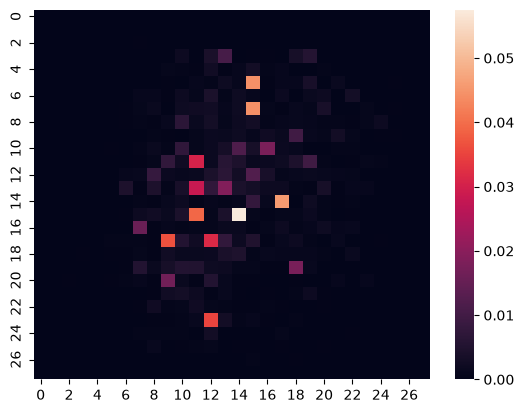

In [32]:
import seaborn as sns

# Visualizing the Feature Importance on the image
sns.heatmap(dt.feature_importances_.reshape(28,28))

### The highlighted columns are very important than the other complete black columns

---

### For Random Forest :

### It take the average of the all importances from all trees.

`FI_k = (1/T) Σ(t = 1 to T) fi_k^(t)`

<Axes: >

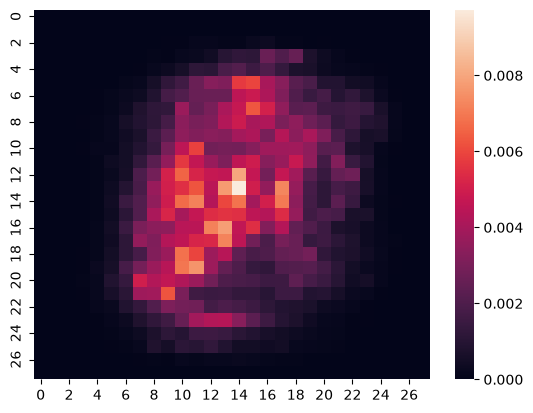

In [13]:
rf = RandomForestClassifier()

rf.fit(X, y)

sns.heatmap(rf.feature_importances_.reshape(28,28))

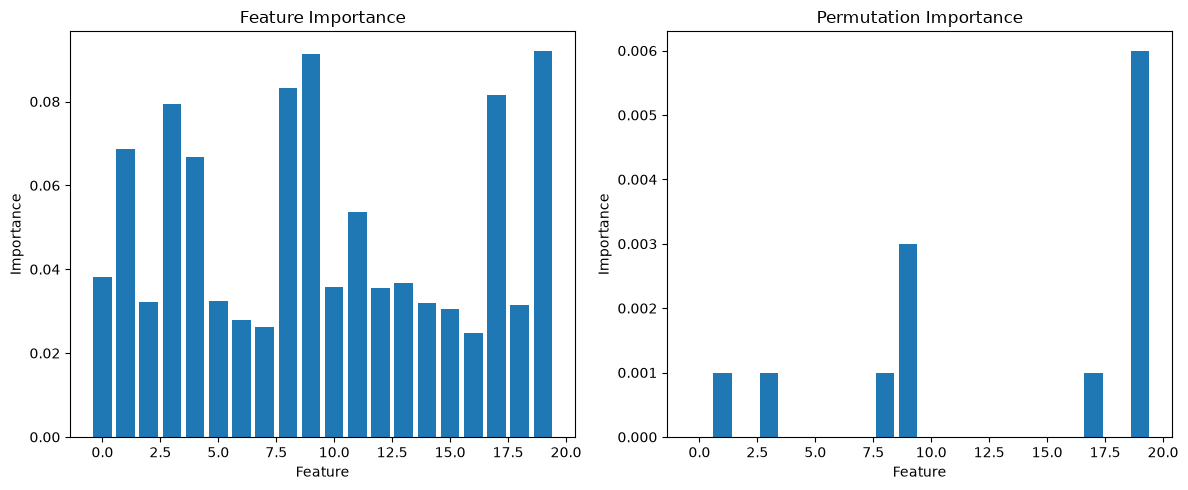

In [35]:
from sklearn.datasets import make_classification

import matplotlib.pyplot as plt

X_new, y_new = make_classification(n_samples=200, n_features=20, n_informative=5, n_redundant=5, random_state=42)

clf_new = RandomForestClassifier(random_state=42)
clf_new.fit(X_new, y_new)


feature_imp = clf_new.feature_importances_


perm_imp = permutation_importance(clf_new, X_new, y_new, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(range(20), feature_imp)
axes[0].set_title('Feature Importance')
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Importance')

axes[1].bar(range(20), perm_imp.importances_mean)
axes[1].set_title('Permutation Importance')
axes[1].set_xlabel('Feature')
axes[1].set_ylabel('Importance')

plt.tight_layout()
plt.show()

### Difference: Permutation importance measures the decrease in model performance when a feature's values are randomly shuffled, while feature importance measures how much each feature contributes during tree construction.